In [2]:
import sys
print(sys.executable)

c:\Users\HP\AppData\Local\Programs\Python\Python314\python.exe


In [3]:
from imblearn.over_sampling import SMOTE


In [4]:
from xgboost import XGBClassifier

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix




In [6]:
# Load cleaned dataset
df = pd.read_csv("../data/cleaned_dataset.csv")

In [7]:
df.dtypes

lead_status                      str
assigned_to                      str
campaign_name                    str
source_type                      str
source_name                      str
Total Leads                    int64
Cost per Lead                float64
Total Cost                   float64
was_contacted                  int64
had_followup                   int64
interaction_hours            float64
first_contact_delay_hours    float64
lead_age                     float64
target                         int64
dtype: object

In [8]:
# One-hot encoding (small categories)
small_columns = ['lead_status', 'source_type']
df = pd.get_dummies(df, columns=small_columns, drop_first=True)

In [9]:
# Frequency encoding (large categories)
for col in ['campaign_name', 'assigned_to', 'source_name']:
    if col in df.columns:
        freq = df[col].value_counts()
        df[col + "_freq"] = df[col].map(freq)
        df.drop(col, axis=1, inplace=True)

In [10]:
# Convert bool to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [11]:
# Split data
X = df.drop('target', axis=1)
y = df['target']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
# -------------------------
# 1. Logistic Regression
# -------------------------
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

In [15]:
print("\nLogistic Regression Results")
print(classification_report(y_test, y_pred))


Logistic Regression Results
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5306
           1       0.66      0.36      0.47       169

    accuracy                           0.97      5475
   macro avg       0.82      0.68      0.73      5475
weighted avg       0.97      0.97      0.97      5475



In [16]:
# -------------------------
# 2. SMOTE + Logistic Regression
# -------------------------
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

lr_sm = LogisticRegression(random_state=42)
lr_sm.fit(X_train_sm, y_train_sm)

y_pred_sm = lr_sm.predict(X_test_scaled)

print("\nSMOTE Logistic Regression Results")
print(classification_report(y_test, y_pred_sm))


SMOTE Logistic Regression Results
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      5306
           1       0.13      0.79      0.23       169

    accuracy                           0.84      5475
   macro avg       0.56      0.81      0.57      5475
weighted avg       0.97      0.84      0.89      5475



In [17]:
# -------------------------
# 3. XGBoost Model
# -------------------------
xgb = XGBClassifier(
    scale_pos_weight=31.4,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Results")
print(classification_report(y_test, y_pred_xgb))


XGBoost Results
              precision    recall  f1-score   support

           0       0.99      0.93      0.96      5306
           1       0.24      0.74      0.37       169

    accuracy                           0.92      5475
   macro avg       0.62      0.83      0.66      5475
weighted avg       0.97      0.92      0.94      5475



In [18]:
# Threshold tuning
y_prob = xgb.predict_proba(X_test)[:, 1]
y_pred_thresh = (y_prob > 0.3).astype(int)

print("\nXGBoost (Threshold 0.3)")
print(confusion_matrix(y_test, y_pred_thresh))



XGBoost (Threshold 0.3)
[[4172 1134]
 [  16  153]]


Model Comparison Table

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [20]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC AUC": roc_auc_score(y_true, y_prob)
    }

In [21]:
# Predictions
lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:,1]

sm_pred = lr_sm.predict(X_test_scaled)
sm_prob = lr_sm.predict_proba(X_test_scaled)[:,1]

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:,1]

In [22]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob
    )
)

results.append(
    evaluate_model(
        "SMOTE Logistic Regression",
        y_test,
        sm_pred,
        sm_prob
    )
)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred,
        xgb_prob
    )
)

In [23]:
comparison_df = pd.DataFrame(results)

print("\nModel Comparison")
print(comparison_df)


Model Comparison
                       Model  Accuracy  Precision    Recall  F1 Score  \
0        Logistic Regression  0.974429   0.655914  0.360947  0.465649   
1  SMOTE Logistic Regression  0.837260   0.134615  0.786982  0.229905   
2                    XGBoost  0.921279   0.244141  0.739645  0.367107   

    ROC AUC  
0  0.916321  
1  0.919886  
2  0.946608  


Plotting ROC Curve

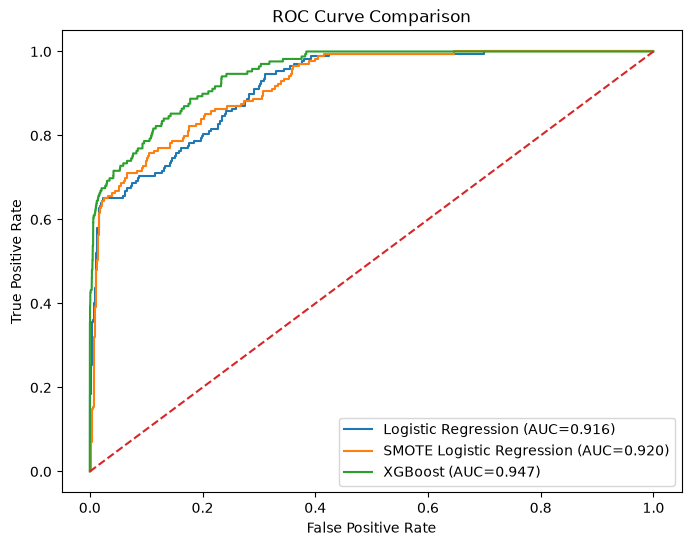

In [25]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
sm_fpr, sm_tpr, _ = roc_curve(y_test, sm_prob)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_prob):.3f})"
)

plt.plot(
    sm_fpr,
    sm_tpr,
    label=f"SMOTE Logistic Regression (AUC={roc_auc_score(y_test, sm_prob):.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC={roc_auc_score(y_test, xgb_prob):.3f})"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.savefig("../images/roc_curve.png", bbox_inches="tight")
plt.show()